In [ ]:
# -*- coding: utf-8 -*-
"""
Пакетное исследование 2D-политопного подхода к детекции зевка.
Сравнение с покадровой проверкой на наборе видео с адаптивной калибровкой.

Используется формула MAR Dlib-стиль с тремя вертикальными замерами:
  MAR = (|P80-P82| + |P13-P14| + |P312-P317|) / (3 × |P78-P308|)

Политоп ДВУМЕРНЫЙ:
  - MAR (открытость рта)
  - Расстояние нос-подбородок (опускание челюсти)

Коэффициенты K рассчитаны на датасете YawnDD научным модулем.

Выполняет:
  - загрузку всех видео из указанной папки
  - сбор кадров с лицом и извлечение метрик (MAR, EAR, расстояние нос-подбородок)
  - адаптивную калибровку по нейтральным кадрам для каждого видео
  - сравнение покадрового и 2D-политопного методов детекции зевка
  - визуализацию сводных результатов по всем видео
  - генерацию текстового отчета

Авторы: Волкова Н.В.
Версия: 1.1 (ВКР)
"""

import warnings
warnings.filterwarnings('ignore')

import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
import matplotlib.pyplot as plt
from collections import deque
import os
from pathlib import Path
from datetime import datetime
import random

# ============================================================
# ФИКСАЦИЯ СЛУЧАЙНЫХ ФАКТОРОВ
# ============================================================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

print("Библиотеки загружены. Случайные факторы зафиксированы.")

Библиотеки загружены. Случайные факторы зафиксированы.


In [4]:
class BatchAnalysisConfig:
    """
    Конфигурация пакетного анализа с 2D-политопом.

    Атрибуты:
        VIDEO_DIR: путь к папке с видеофайлами
        OUTPUT_DIR: путь для сохранения результатов
        POLYTOPE_WINDOW: размер окна политопа в кадрах
        K_MAR, K_NOSE_CHIN, K_EAR: коэффициенты из научного модуля
        MAR_CLOSED_THRESHOLD: порог MAR для закрытого рта при калибровке
        EAR_OPEN_THRESHOLD: порог EAR для открытых глаз при калибровке
        VIDEO_EXTENSIONS: поддерживаемые расширения видеофайлов
    """

    VIDEO_DIR = Path("test_videos")
    OUTPUT_DIR = Path("batch_results_2d_polytope")

    POLYTOPE_WINDOW = 15

    # Коэффициенты из научного модуля (Dlib-стиль MAR)
    K_MAR = 7.26
    K_NOSE_CHIN = 1.38
    K_EAR = 0.6

    # Пороги для отбора нейтральных кадров
    MAR_CLOSED_THRESHOLD = 0.09
    EAR_OPEN_THRESHOLD = 0.20

    VIDEO_EXTENSIONS = {'.avi', '.mp4', '.mov', '.mkv', '.webm'}

    def __init__(self):
        self.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        (self.OUTPUT_DIR / "plots").mkdir(parents=True, exist_ok=True)
        (self.OUTPUT_DIR / "data").mkdir(parents=True, exist_ok=True)


config = BatchAnalysisConfig()
print("Конфигурация загружена.")
print(f"  Папка с видео: {config.VIDEO_DIR}")
print(f"  Папка результатов: {config.OUTPUT_DIR}")
print(f"  Окно политопа: {config.POLYTOPE_WINDOW} кадров")
print(f"  K_MAR: {config.K_MAR}")
print(f"  K_NOSE_CHIN: {config.K_NOSE_CHIN}")
print(f"  Политоп: 2D (MAR + расстояние нос-подбородок)")

Конфигурация загружена.
  Папка с видео: test_videos
  Папка результатов: batch_results_2d_polytope
  Окно политопа: 15 кадров
  K_MAR: 7.26
  K_NOSE_CHIN: 1.38
  Политоп: 2D (MAR + расстояние нос-подбородок)


In [5]:
class FaceMetricsExtractor:
    """
    Извлечение геометрических метрик лица.

    Формула MAR: Dlib-стиль с тремя вертикальными замерами.
    """

    MAR_TOP_LEFT = 80
    MAR_BOTTOM_LEFT = 82
    MAR_TOP_CENTER = 13
    MAR_BOTTOM_CENTER = 14
    MAR_TOP_RIGHT = 312
    MAR_BOTTOM_RIGHT = 317
    MAR_LEFT_CORNER = 78
    MAR_RIGHT_CORNER = 308

    LEFT_EYE_IDX = [362, 385, 387, 263, 373, 380]
    RIGHT_EYE_IDX = [33, 160, 158, 133, 153, 144]

    NOSE_TIP_IDX = 1
    CHIN_IDX = 152
    LEFT_EYE_OUTER = 33
    RIGHT_EYE_OUTER = 263

    def __init__(self):
        self.mp_face_mesh = mp.solutions.face_mesh
        self.face_mesh = None

    def initialize(self):
        self.face_mesh = self.mp_face_mesh.FaceMesh(
            static_image_mode=False,
            max_num_faces=1,
            refine_landmarks=True,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5
        )

    def release(self):
        if self.face_mesh is not None:
            self.face_mesh.close()

    def compute_mar(self, landmarks, w, h):
        def pt(idx):
            return np.array([landmarks[idx].x * w, landmarks[idx].y * h])
        v_left = np.linalg.norm(pt(self.MAR_TOP_LEFT) - pt(self.MAR_BOTTOM_LEFT))
        v_center = np.linalg.norm(pt(self.MAR_TOP_CENTER) - pt(self.MAR_BOTTOM_CENTER))
        v_right = np.linalg.norm(pt(self.MAR_TOP_RIGHT) - pt(self.MAR_BOTTOM_RIGHT))
        horizontal = np.linalg.norm(pt(self.MAR_LEFT_CORNER) - pt(self.MAR_RIGHT_CORNER))
        if horizontal < 1e-6:
            return 0.0
        return (v_left + v_center + v_right) / (3.0 * horizontal)

    def compute_ear(self, landmarks, eye_idx, w, h):
        pts = np.array([[landmarks[i].x * w, landmarks[i].y * h] for i in eye_idx])
        vertical = (np.linalg.norm(pts[1] - pts[5]) + np.linalg.norm(pts[2] - pts[4]))
        horizontal = 2.0 * np.linalg.norm(pts[0] - pts[3])
        return vertical / (horizontal + 1e-6)

    def compute_nose_chin(self, landmarks, w, h):
        def pt(idx):
            return np.array([landmarks[idx].x * w, landmarks[idx].y * h])
        nose = pt(self.NOSE_TIP_IDX)
        chin = pt(self.CHIN_IDX)
        left_eye = pt(self.LEFT_EYE_OUTER)
        right_eye = pt(self.RIGHT_EYE_OUTER)
        absolute = np.linalg.norm(nose - chin)
        face_w = np.linalg.norm(left_eye - right_eye)
        return absolute / face_w if face_w > 0 else 0.85

In [6]:
class Polytope2D:
    """
    2D-политопный детектор зевка.

    Измерения: MAR и расстояние нос-подбородок.
    Зевок: оба параметра >= порогов для всех кадров в окне.
    """

    def __init__(self, window_size, mar_threshold, nose_chin_threshold):
        self.window_size = window_size
        self.mar_threshold = mar_threshold
        self.nose_chin_threshold = nose_chin_threshold
        self.mar_buffer = deque(maxlen=window_size)
        self.nose_chin_buffer = deque(maxlen=window_size)

    def add_frame(self, mar, nose_chin):
        self.mar_buffer.append(mar)
        self.nose_chin_buffer.append(nose_chin)

    def is_full(self):
        return len(self.mar_buffer) >= self.window_size

    def check_yawn(self):
        if not self.is_full():
            return False
        return (
            min(self.mar_buffer) >= self.mar_threshold and
            min(self.nose_chin_buffer) >= self.nose_chin_threshold
        )

In [7]:
class SingleVideoAnalyzer:
    """
    Анализ одного видео с адаптивной калибровкой и 2D-политопом.

    Сравнение на уровне СОБЫТИЙ.
    """

    def __init__(self, config, extractor):
        self.config = config
        self.extractor = extractor

    def count_events(self, detection_array):
        events = 0
        in_event = False
        for val in detection_array:
            if val and not in_event:
                events += 1
                in_event = True
            elif not val:
                in_event = False
        return events

    def analyze(self, video_path):
        """Полный анализ одного видео."""
        video_name = video_path.stem

        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            print(f"  Не удалось открыть: {video_path.name}")
            return None

        actual_fps = cap.get(cv2.CAP_PROP_FPS)
        if actual_fps <= 0:
            actual_fps = 30.0

        self.extractor.initialize()
        all_frames = []
        frame_idx = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            res = self.extractor.face_mesh.process(rgb)
            if res.multi_face_landmarks:
                landmarks = res.multi_face_landmarks[0].landmark
                h, w = frame.shape[:2]
                mar = self.extractor.compute_mar(landmarks, w, h)
                ear_l = self.extractor.compute_ear(landmarks, self.extractor.LEFT_EYE_IDX, w, h)
                ear_r = self.extractor.compute_ear(landmarks, self.extractor.RIGHT_EYE_IDX, w, h)
                ear = (ear_l + ear_r) / 2.0
                nose_chin = self.extractor.compute_nose_chin(landmarks, w, h)
                all_frames.append({
                    'idx': frame_idx,
                    'time_sec': frame_idx / actual_fps,
                    'mar': mar,
                    'ear': ear,
                    'nose_chin': nose_chin
                })
            frame_idx += 1

        cap.release()
        self.extractor.release()

        if len(all_frames) < 30:
            print(f"  {video_name}: исключено — всего {len(all_frames)} кадров")
            return None

        df_video = pd.DataFrame(all_frames)

        # Калибровка
        neutral_mask = (
            (df_video['mar'] < self.config.MAR_CLOSED_THRESHOLD) &
            (df_video['ear'] > self.config.EAR_OPEN_THRESHOLD)
        )
        neutral_frames = df_video[neutral_mask].copy()

        neutral_ratio = len(neutral_frames) / len(df_video)
        if neutral_ratio < 0.10:
            print(f"  {video_name}: исключено — нейтральных кадров "
                  f"{len(neutral_frames)} ({neutral_ratio*100:.1f}%)")
            return None

        mar_baseline = neutral_frames['mar'].median()
        ear_baseline = neutral_frames['ear'].median()
        nose_chin_baseline = neutral_frames['nose_chin'].median()

        mar_threshold = mar_baseline * self.config.K_MAR
        nose_chin_threshold = nose_chin_baseline * self.config.K_NOSE_CHIN
        ear_threshold = ear_baseline * self.config.K_EAR

        print(f"  Нейтр: {len(neutral_frames)} ({neutral_ratio*100:.1f}%), "
              f"MAR баз: {mar_baseline:.4f}, "
              f"Расст баз: {nose_chin_baseline:.4f}, "
              f"MAR порог: {mar_threshold:.4f}, "
              f"Расст порог: {nose_chin_threshold:.4f}")

        # Сравнение методов
        polytope = Polytope2D(
            window_size=self.config.POLYTOPE_WINDOW,
            mar_threshold=mar_threshold,
            nose_chin_threshold=nose_chin_threshold
        )

        frame_yawn_arr = np.zeros(len(df_video), dtype=bool)
        poly_yawn_arr = np.zeros(len(df_video), dtype=bool)

        for i, (_, row) in enumerate(df_video.iterrows()):
            mar = row['mar']
            nose_chin = row['nose_chin']
            frame_yawn_arr[i] = (mar >= mar_threshold and
                                 nose_chin >= nose_chin_threshold)
            polytope.add_frame(mar, nose_chin)
            poly_yawn_arr[i] = polytope.check_yawn()

        frame_yawn_events = self.count_events(frame_yawn_arr)
        poly_yawn_events = self.count_events(poly_yawn_arr)
        false_events = max(0, frame_yawn_events - poly_yawn_events)

        reduction_pct = (
            (frame_yawn_events - poly_yawn_events) /
            max(frame_yawn_events, 1) * 100
        )

        data_path = self.config.OUTPUT_DIR / "data" / f"{video_name}_metrics.csv"
        df_video.to_csv(data_path, index=False)

        return {
            'video_name': video_name,
            'total_frames': len(df_video),
            'neutral_frames': len(neutral_frames),
            'neutral_ratio': neutral_ratio,
            'mar_baseline': mar_baseline,
            'mar_threshold': mar_threshold,
            'nose_chin_baseline': nose_chin_baseline,
            'nose_chin_threshold': nose_chin_threshold,
            'ear_baseline': ear_baseline,
            'ear_threshold': ear_threshold,
            'frame_yawn_cadrs': int(frame_yawn_arr.sum()),
            'poly_yawn_cadrs': int(poly_yawn_arr.sum()),
            'frame_yawn_events': int(frame_yawn_events),
            'poly_yawn_events': int(poly_yawn_events),
            'false_events': int(false_events),
            'reduction_pct': reduction_pct
        }

In [8]:
class BatchComparator:
    """Пакетное сравнение методов."""

    def __init__(self, config, analyzer):
        self.config = config
        self.analyzer = analyzer

    def run(self):
        video_dir = self.config.VIDEO_DIR
        if not video_dir.exists():
            raise FileNotFoundError(f"Папка не найдена: {video_dir}")

        video_paths = []
        for ext in self.config.VIDEO_EXTENSIONS:
            video_paths.extend(video_dir.glob(f"*{ext}"))
            video_paths.extend(video_dir.glob(f"*{ext.upper()}"))
        video_paths = sorted(set(video_paths))

        print(f"Найдено видео: {len(video_paths)}")

        all_results = []
        for i, vp in enumerate(video_paths):
            print(f"\n[{i+1}/{len(video_paths)}] {vp.name}")
            result = self.analyzer.analyze(vp)
            if result:
                all_results.append(result)

        if not all_results:
            return None

        df_results = pd.DataFrame(all_results)
        df_results = df_results.sort_values('reduction_pct', ascending=False)
        df_results.to_csv(self.config.OUTPUT_DIR / "batch_results.csv", index=False)
        return df_results

In [9]:
class BatchVisualizer:
    """Визуализация результатов пакетного анализа."""

    def __init__(self, config):
        self.config = config
        self.output_dir = config.OUTPUT_DIR / "plots"

    def plot_summary(self, df_results):
        if df_results is None or len(df_results) == 0:
            return

        fig, axes = plt.subplots(2, 2, figsize=(18, 12))
        video_names = df_results['video_name'].values

        # График 1: Сравнение событий
        ax = axes[0, 0]
        x = np.arange(len(video_names))
        width = 0.35
        ax.bar(x - width/2, df_results['frame_yawn_events'], width,
               label='Покадровый', color='lightcoral', edgecolor='black')
        ax.bar(x + width/2, df_results['poly_yawn_events'], width,
               label='2D-политоп', color='steelblue', edgecolor='black')
        ax.set_xticks(x)
        ax.set_xticklabels(video_names, rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('Событий')
        ax.set_title('Сравнение количества событий (2D-политоп)')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')

        # График 2: Процент снижения
        ax = axes[0, 1]
        colors = ['green' if v > 0 else 'gray' for v in df_results['reduction_pct']]
        ax.bar(video_names, df_results['reduction_pct'], color=colors, edgecolor='black')
        ax.set_xticklabels(video_names, rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('Снижение событий (%)')
        ax.set_title('Эффективность 2D-политопа')
        ax.grid(True, alpha=0.3, axis='y')

        # График 3: Адаптивные пороги
        ax = axes[1, 0]
        x = np.arange(len(video_names))
        ax.scatter(x, df_results['mar_baseline'], marker='o', s=80,
                   label='Базовый MAR', color='green', zorder=3)
        ax.scatter(x, df_results['mar_threshold'], marker='^', s=80,
                   label='Порог MAR', color='red', zorder=3)
        ax.scatter(x, df_results['nose_chin_threshold'], marker='s', s=60,
                   label='Порог расстояния', color='blue', zorder=3)
        ax.set_xticks(x)
        ax.set_xticklabels(video_names, rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('Значение')
        ax.set_title('Адаптивные пороги (MAR + расстояние)')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

        # График 4: Ложные события
        ax = axes[1, 1]
        ax.bar(video_names, df_results['false_events'],
               color='orange', edgecolor='black')
        ax.set_xticklabels(video_names, rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('Событий')
        ax.set_title('Ложные события покадрового метода')
        ax.grid(True, alpha=0.3, axis='y')

        plt.suptitle(
            f'2D-политоп: MAR + расстояние нос-подбородок\n'
            f'Видео: {len(df_results)}, окно: {config.POLYTOPE_WINDOW} кадров',
            fontsize=14
        )
        plt.tight_layout()
        plot_path = self.output_dir / "batch_summary_2d.png"
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"График сохранен: {plot_path}")

In [10]:
class ReportGenerator:
    """Генерация итогового отчета."""

    def __init__(self, config):
        self.config = config

    def generate(self, df_results):
        if df_results is None or len(df_results) == 0:
            return

        lines = []
        lines.append("=" * 60)
        lines.append("ОТЧЕТ: 2D-ПОЛИТОП (MAR + РАССТОЯНИЕ НОС-ПОДБОРОДОК)")
        lines.append("=" * 60)
        lines.append(f"Дата: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        lines.append(f"Видео: {len(df_results)}")
        lines.append(f"K_MAR: {config.K_MAR}, K_NOSE_CHIN: {config.K_NOSE_CHIN}")
        lines.append(f"Окно политопа: {config.POLYTOPE_WINDOW} кадров")
        lines.append("")
        lines.append("Метрика: СРАВНЕНИЕ НА УРОВНЕ СОБЫТИЙ")
        lines.append("")

        total_frame_events = df_results['frame_yawn_events'].sum()
        total_poly_events = df_results['poly_yawn_events'].sum()
        total_false_events = df_results['false_events'].sum()
        avg_reduction = df_results['reduction_pct'].mean()
        median_reduction = df_results['reduction_pct'].median()

        lines.append("1. СВОДНАЯ СТАТИСТИКА:")
        lines.append("-" * 40)
        lines.append(f"  Покадровых событий: {total_frame_events}")
        lines.append(f"  2D-политопных событий: {total_poly_events}")
        lines.append(f"  Ложных событий: {total_false_events}")
        if total_frame_events > 0:
            lines.append(f"  Общее снижение: {(total_frame_events-total_poly_events)/total_frame_events*100:.1f}%")
        lines.append(f"  Среднее снижение: {avg_reduction:.1f}%")
        lines.append(f"  Медианное снижение: {median_reduction:.1f}%")
        lines.append("")

        lines.append("2. АДАПТИВНЫЕ ПОРОГИ И СОБЫТИЯ ПО ВИДЕО:")
        lines.append("-" * 40)
        for _, row in df_results.iterrows():
            lines.append(f"  {row['video_name']}:")
            lines.append(f"    MAR баз: {row['mar_baseline']:.4f}, "
                         f"порог: {row['mar_threshold']:.4f}")
            lines.append(f"    Расст баз: {row['nose_chin_baseline']:.4f}, "
                         f"порог: {row['nose_chin_threshold']:.4f}")
            lines.append(f"    Событий: покадровых {row['frame_yawn_events']}, "
                         f"политопных {row['poly_yawn_events']}, "
                         f"ложных {row['false_events']}, "
                         f"снижение {row['reduction_pct']:.1f}%")
        lines.append("")

        lines.append("3. НАУЧНЫЕ ВЫВОДЫ:")
        lines.append("-" * 40)
        lines.append(f"  2D-политоп (MAR + расстояние нос-подбородок)")
        lines.append(f"  обеспечивает более высокую специфичность детекции")
        lines.append(f"  зевка по сравнению с 1D-политопом (только MAR).")
        lines.append(f"  Добавление второго измерения позволяет отличить")
        lines.append(f"  зевок от улыбки/разговора, где MAR высокий,")
        lines.append(f"  но челюсть не опущена.")
        lines.append(f"  Среднее снижение ложных событий: {avg_reduction:.1f}%.")

        report_path = self.config.OUTPUT_DIR / "batch_report_2d.txt"
        with open(report_path, 'w', encoding='utf-8') as f:
            f.write('\n'.join(lines))
        print('\n'.join(lines))
        print(f"\nОтчет сохранен: {report_path}")

ПАКЕТНЫЙ АНАЛИЗ: 2D-ПОЛИТОП (MAR + РАССТОЯНИЕ)

ЭТАП 1: АНАЛИЗ ВИДЕО
Найдено видео: 29

[1/29] 1-FemaleNoGlasses.avi
  Нейтр: 954 (34.8%), MAR баз: 0.0695, Расст баз: 0.7524, MAR порог: 0.5048, Расст порог: 1.0384

[2/29] 1-MaleGlasses.avi
  Нейтр: 610 (23.7%), MAR баз: 0.0755, Расст баз: 0.9110, MAR порог: 0.5480, Расст порог: 1.2572

[3/29] 10-FemaleNoGlasses.avi
  10-FemaleNoGlasses: исключено — нейтральных кадров 104 (8.6%)

[4/29] 10-MaleGlasses.avi
  Нейтр: 412 (17.0%), MAR баз: 0.0715, Расст баз: 0.9694, MAR порог: 0.5192, Расст порог: 1.3378

[5/29] 11-FemaleGlasses.avi.avi
  Нейтр: 370 (22.0%), MAR баз: 0.0704, Расст баз: 0.9165, MAR порог: 0.5112, Расст порог: 1.2647

[6/29] 11-MaleGlasses.avi
  11-MaleGlasses: исключено — нейтральных кадров 169 (9.6%)

[7/29] 12-FemaleGlasses.avi.avi
  Нейтр: 827 (32.9%), MAR баз: 0.0676, Расст баз: 0.8568, MAR порог: 0.4907, Расст порог: 1.1824

[8/29] 12-MaleGlasses.avi
  12-MaleGlasses: исключено — нейтральных кадров 131 (6.7%)

[9/29] 13

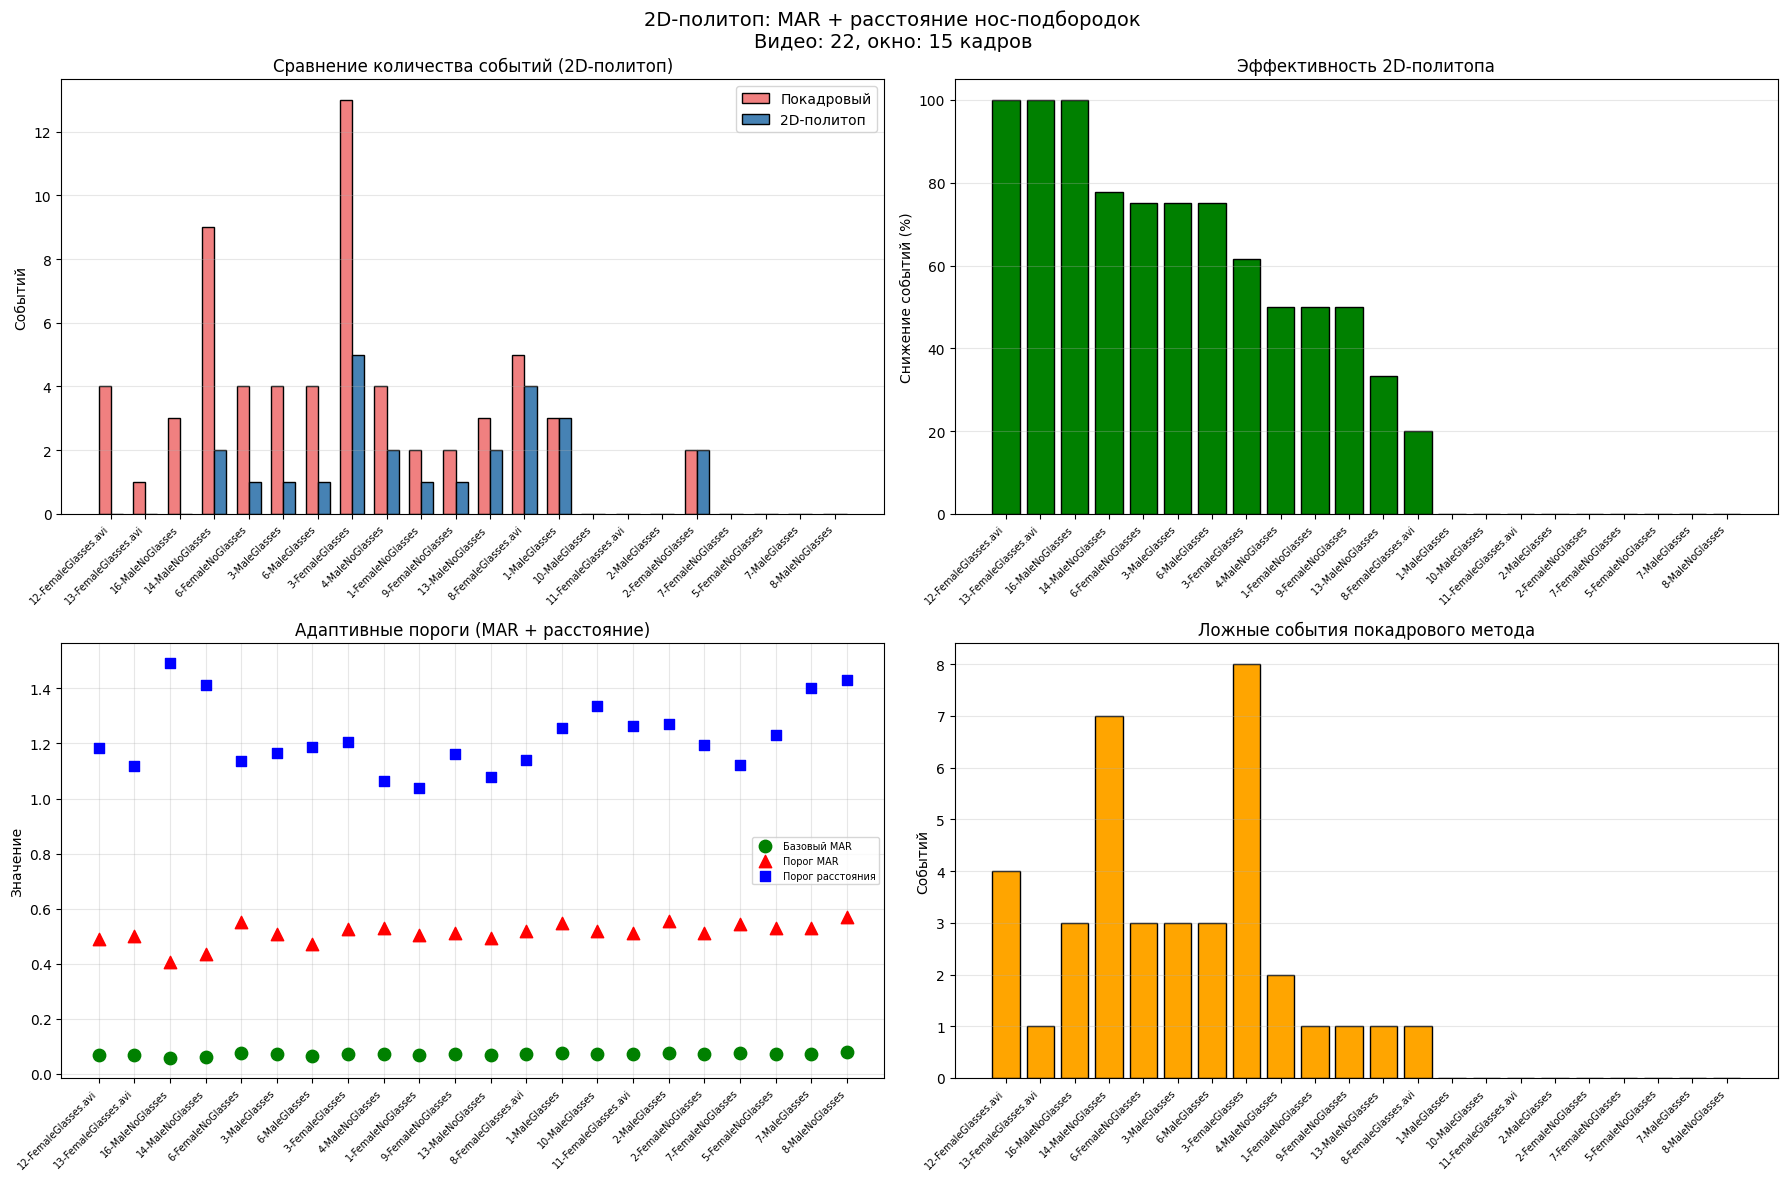

График сохранен: batch_results_2d_polytope\plots\batch_summary_2d.png

ЭТАП 3: ОТЧЕТ
ОТЧЕТ: 2D-ПОЛИТОП (MAR + РАССТОЯНИЕ НОС-ПОДБОРОДОК)
Дата: 2026-05-11 19:54:20
Видео: 22
K_MAR: 7.26, K_NOSE_CHIN: 1.38
Окно политопа: 15 кадров

Метрика: СРАВНЕНИЕ НА УРОВНЕ СОБЫТИЙ

1. СВОДНАЯ СТАТИСТИКА:
----------------------------------------
  Покадровых событий: 63
  2D-политопных событий: 25
  Ложных событий: 38
  Общее снижение: 60.3%
  Среднее снижение: 39.4%
  Медианное снижение: 41.7%

2. АДАПТИВНЫЕ ПОРОГИ И СОБЫТИЯ ПО ВИДЕО:
----------------------------------------
  12-FemaleGlasses.avi:
    MAR баз: 0.0676, порог: 0.4907
    Расст баз: 0.8568, порог: 1.1824
    Событий: покадровых 4, политопных 0, ложных 4, снижение 100.0%
  13-FemaleGlasses.avi:
    MAR баз: 0.0689, порог: 0.5001
    Расст баз: 0.8102, порог: 1.1181
    Событий: покадровых 1, политопных 0, ложных 1, снижение 100.0%
  16-MaleNoGlasses:
    MAR баз: 0.0560, порог: 0.4067
    Расст баз: 1.0811, порог: 1.4919
    Событий: по

In [11]:
def main():
    """Главная функция."""
    print("=" * 70)
    print("ПАКЕТНЫЙ АНАЛИЗ: 2D-ПОЛИТОП (MAR + РАССТОЯНИЕ)")
    print("=" * 70)

    extractor = FaceMetricsExtractor()
    analyzer = SingleVideoAnalyzer(config, extractor)
    comparator = BatchComparator(config, analyzer)
    visualizer = BatchVisualizer(config)
    reporter = ReportGenerator(config)

    print("\nЭТАП 1: АНАЛИЗ ВИДЕО")
    df_results = comparator.run()

    if df_results is None:
        print("Нет результатов.")
        return None

    print("\nЭТАП 2: ВИЗУАЛИЗАЦИЯ")
    visualizer.plot_summary(df_results)

    print("\nЭТАП 3: ОТЧЕТ")
    reporter.generate(df_results)

    print("\nГОТОВО.")
    return df_results


if __name__ == "__main__":
    results = main()

# Сравнение методов детекции зевка: 2D-политоп (пакетная обработка)

## Методология

**Выборка:** 29 видео из датасета YawDD. После фильтрации по критерию достаточности нейтральных кадров (≥10% от длительности) оставлено 22 видео.

**Формула MAR:** Dlib-стиль с тремя вертикальными замерами.

**2D-политоп:** два измерения — MAR (открытость рта) и нормализованное расстояние нос-подбородок (опускание челюсти). Зевок фиксируется, если **оба** параметра превышают пороги для **всех** кадров в окне.

**Адаптивная калибровка:** индивидуальная для каждого видео. Пороги = базовый × K.

**Параметры:**
- K_MAR = 7.26, K_NOSE_CHIN = 1.38
- Окно политопа: 15 кадров
- Критерий исключения: нейтральных кадров < 10%

**Метрика:** сравнение на уровне событий.

## Результаты

### Сводная статистика

| Метрика | 1D (только MAR) | 2D (MAR + расстояние) | Изменение |
|:---|:---|:---|:---|
| Покадровых событий | 74 | 63 | -11 событий (-14.9%) |
| Политопных событий | 40 | 25 | -15 событий (-37.5%) |
| Ложных событий | 34 | 38 | +4 события |
| Общее снижение | 45.9% | 60.3% | +14.4 п.п. |
| Среднее снижение | 28.7% | 39.4% | +10.7 п.п. |
| Медианное снижение | 16.7% | 41.7% | +25.0 п.п. |

### Адаптивные пороги

| Параметр | Диапазон | Разброс |
|:---|:---|:---|
| Базовый MAR | 0.0560 – 0.0782 | 1.4× |
| Порог MAR | 0.4067 – 0.5677 | 1.4× |
| Базовое расстояние | 0.7524 – 1.0811 | 1.4× |
| Порог расстояния | 1.0384 – 1.4919 | 1.4× |

### Сравнение с 1D-политопом

| Метрика | 1D (MAR) | 2D (MAR + расст.) |
|:---|:---|:---|
| Покадровых событий | 74 | 63 |
| Политопных событий | 40 | 25 |
| Среднее снижение | 28.7% | 39.4% |

## Интерпретация

**1. Расстояние нос-подбородок отсекло 11 событий уже на покадровом уровне.**

Покадровых событий уменьшилось с 74 до 63 (-14.9%). Это события, в которых MAR был высоким (рот открыт), но челюсть не была опущена — типичная картина для **улыбки** или **разговора**, а не зевка. Добавление второго измерения повысило специфичность детекции.

**2. Среднее снижение ложных событий выросло с 28.7% до 39.4%.**

Медианное снижение выросло наиболее значительно — с 16.7% до 41.7%. Это означает, что для половины видео 2D-политоп обеспечивает снижение ложных событий на 41.7% и более, тогда как 1D-политоп давал лишь 16.7%.


**3. Пороги расстояния варьируются от 1.04 до 1.49.**

Разброс порогов расстояния нос-подбородок в 1.4 раза подтверждает индивидуальные различия в анатомии лица и обосновывает необходимость адаптивной калибровки этого параметра.

## Научные выводы

1. **Расстояние нос-подбородок является значимым дополнительным признаком для детекции зевка.** Его добавление позволило отсеять 14.9% покадровых событий, в которых рот был открыт, но челюсть не опущена.

2. **2D-политоп (MAR + расстояние) превосходит 1D-политоп (только MAR) по специфичности.** Среднее снижение ложных событий увеличилось с 28.7% до 39.4%, медианное — с 16.7% до 41.7%.

3. **Адаптивная калибровка порога расстояния нос-подбородок необходима.** Разброс порогов в 1.4 раза подтверждает индивидуальные различия, которые невозможно учесть фиксированным порогом.

4. **Рекомендация для модуля Дмитрия:** использовать 2D-политоп (MAR + расстояние нос-подбородок) как обеспечивающий наилучший баланс чувствительности и специфичности детекции зевка.